In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(filepath_or_buffer='data.csv')
data.head(10)

,img_path,age,gender
0,Dataset/part1\100_1_0_20170110183726390.jpg,100,1
1,Dataset/part1\100_1_2_20170105174847679.jpg,100,1
2,Dataset/part1\100_1_2_20170110182836729.jpg,100,1
3,Dataset/part1\101_1_2_20170105174739309.jpg,101,1
4,Dataset/part1\10_0_0_20161220222308131.jpg,10,0
5,Dataset/part1\10_0_0_20170103200329407.jpg,10,0
6,Dataset/part1\10_0_0_20170103200522151.jpg,10,0
7,Dataset/part1\10_0_0_20170103233459275.jpg,10,0
8,Dataset/part1\10_0_0_20170104013211746.jpg,10,0
9,Dataset/part1\10_0_0_20170110215927291.jpg,10,0


In [19]:
print(data['gender'].value_counts().sort_index())

gender
0    12581
1    11523
3        1
Name: count, dtype: int64


In [20]:
data = data[(data['gender']==0)|(data['gender']==1)]

In [22]:
print(data['age'].describe())   # min, max, mean, median, квартили
print("Старше 70:", (data['age'] > 70).sum())
print("Младше 3:", (data['age'] < 3).sum())

count    24104.000000
mean        33.043188
std         20.138956
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64
Старше 70: 1266
Младше 3: 1813


Распределение возрастов

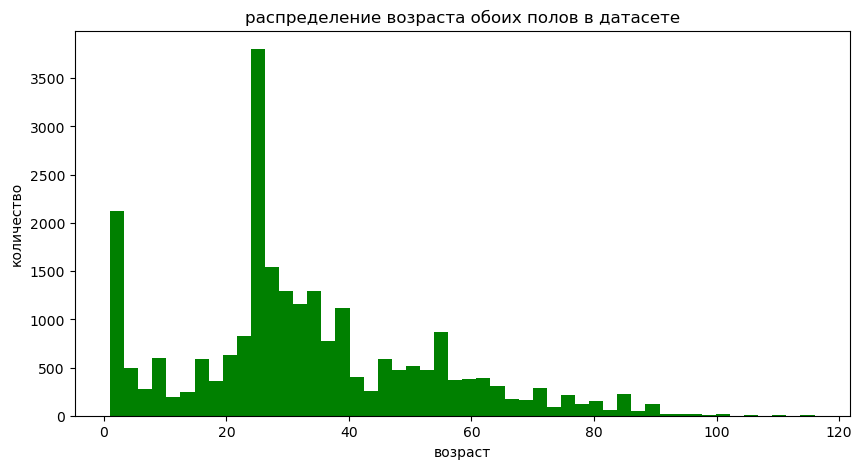

In [23]:
plt.figure(figsize=(10,5))
plt.hist(data['age'], bins=50, color='green')
plt.xlabel('возраст')
plt.ylabel('количество')
plt.title('распределение возраста обоих полов в датасете')
plt.show()

Text(0.5, 1.0, 'распределение возраста среди мужчин')

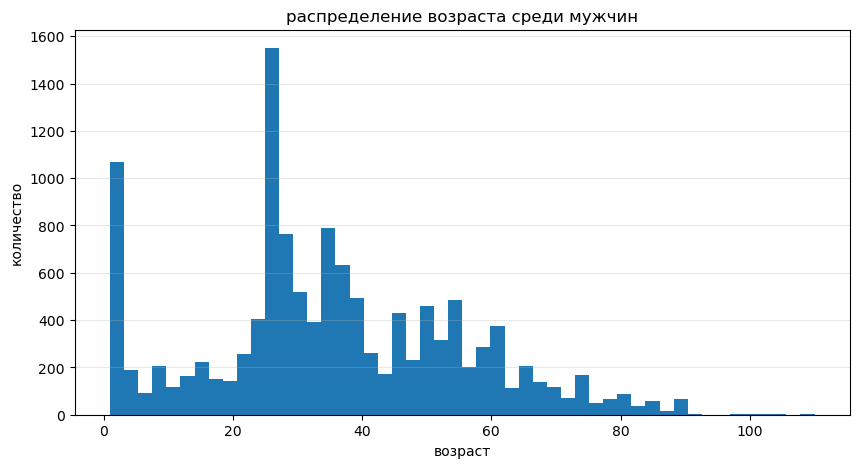

In [24]:
plt.figure(figsize=(10,5))
plt.grid(axis='y', alpha=0.3)
plt.hist(data.loc[data['gender']==0,'age'], bins=50)
plt.xlabel('возраст')
plt.ylabel('количество')
plt.title('распределение возраста среди мужчин')

Text(0.5, 1.0, 'распределение возраста среди женщин')

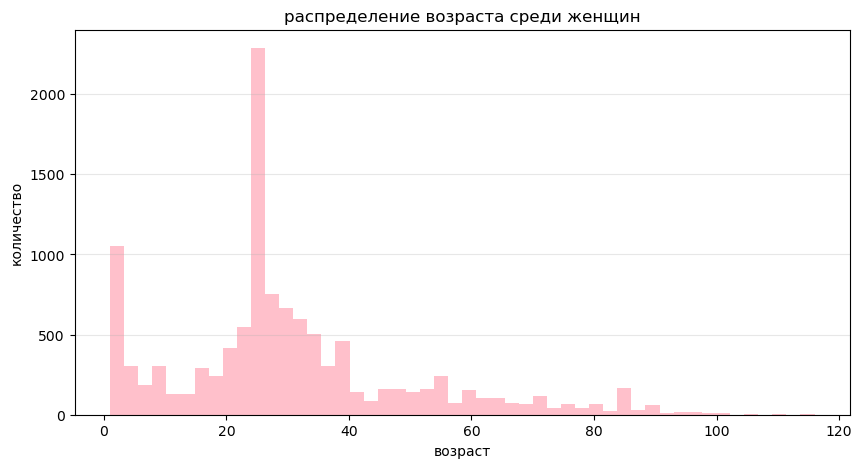

In [25]:
plt.figure(figsize=(10,5))
plt.grid(axis='y', alpha=0.3)
plt.hist(data.loc[data['gender']==1,'age'], bins=50, color='pink')
plt.xlabel('возраст')
plt.ylabel('количество')
plt.title('распределение возраста среди женщин')

In [29]:
# min, max, mean, median, квартили
print("Старше 40:", (data['age'] > 40).sum())
print("Младше 20:", (data['age'] < 20).sum())

Старше 40: 6778
Младше 20: 4889


In [31]:
print("1-2:", ((data['age'] >= 1) & (data['age'] <= 2)).sum())
print("3-20:", ((data['age'] >= 3) & (data['age'] <= 20)).sum())
print("20-40:",   ((data['age'] >= 21) & (data['age'] <= 40)).sum())

print("40-60:", ((data['age'] >= 41) & (data['age'] <= 60)).sum())
print("60-80:", ((data['age'] >= 61) & (data['age'] < 80)).sum())
print("80+:",   (data['age'] >= 80).sum())

1-2: 1813
3-20: 3361
20-40: 12152
40-60: 4328
60-80: 1751
80+: 699


In [32]:
print(data[data['age'] > 100]['age'].value_counts().sort_index())
print("Всего старше 100:", (data['age'] > 100).sum())
print("Максимум:", data['age'].max())

age
101    2
103    1
105    5
110    6
111    1
115    3
116    4
Name: count, dtype: int64
Всего старше 100: 22
Максимум: 116


умеренный дисбаланс по возрасту: перекос в сторону 20-40 лет, после 60 данных мало, после 90 данных почти нет

проблема возникает для 60+ изза малого кол-ва примеров и наблюдается всплекс у младенцев 1-2(может вызвать перекос предсказаний в сторону малых возрастов)



распределние пола

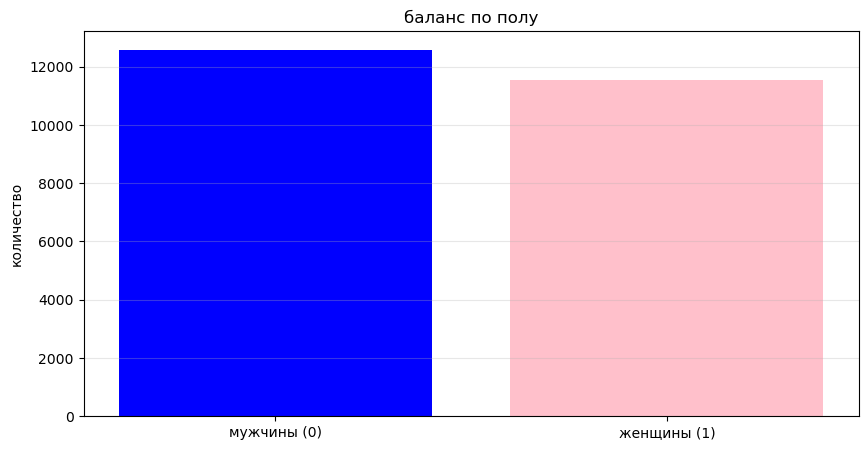

In [26]:
plt.figure(figsize=(10,5))
plt.grid(axis='y', alpha=0.3)
plt.bar(['мужчины (0)', 'женщины (1)'], data['gender'].value_counts().sort_index(), color=['blue','pink'])
plt.ylabel('количество')
plt.title('баланс по полу')
plt.show()

Баланс по полу почти равный, значит вес классов не нужен

Text(0, 0.5, 'количество')

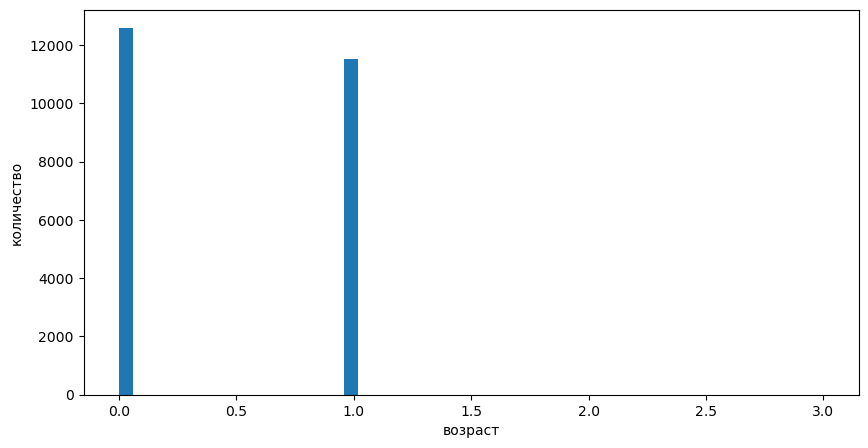

In [5]:
plt.figure(figsize=(10,5))
plt.hist(data['gender'], bins=50)
plt.xlabel('возраст')
plt.ylabel('количество')

совместное распределение AGExGENDER

<Figure size 800x500 with 0 Axes>

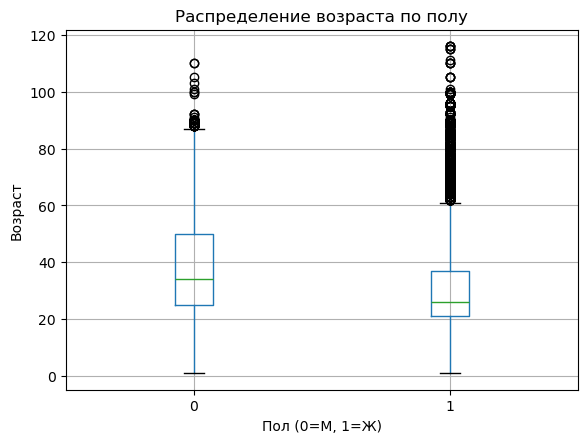

In [33]:
plt.figure(figsize=(8,5))
data.boxplot(column='age', by='gender')
plt.xlabel('Пол (0=М, 1=Ж)')
plt.ylabel('Возраст')
plt.title('Распределение возраста по полу')
plt.suptitle('')  
plt.show()

In [37]:
print(data.groupby('gender')['age'].describe())

          count       mean        std  min   25%   50%   75%    max
gender                                                             
0       12581.0  35.493601  19.956695  1.0  25.0  34.0  50.0  110.0
1       11523.0  30.367786  19.996922  1.0  21.0  26.0  37.0  116.0


Мужчины : основная масса 23-50
Женщины : основаня масса 21-39

Мужчины заметно старше и медиана у них выше

то есть молодых женщин в датасете больше, а среди среди мужчин больше мучжин ср возраста

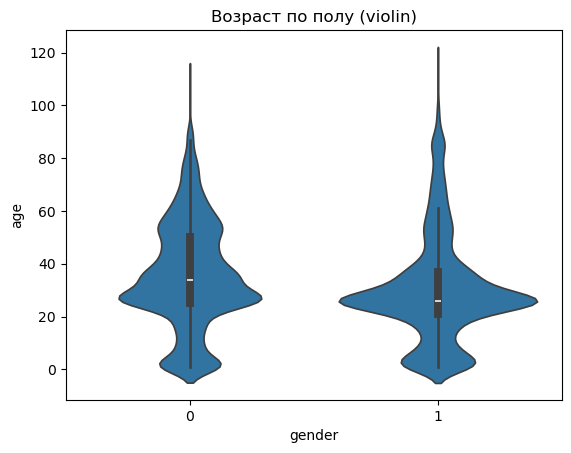

In [38]:
sns.violinplot(data=data, x = 'gender', y= 'age')
plt.title('Возраст по полу (violin)')
plt.show()

In [41]:

np.corrcoef(data['gender'],data['age'])

array([[ 1.        , -0.12714118],
       [-0.12714118,  1.        ]])

по point-biserial корреляции видно что можно учить обе головы нейросети параллельно

In [42]:
from scipy.stats import ttest_ind
m_age = data[data['gender']==0]['age']
w_age = data[data['gender']==1]['age']
print(ttest_ind(m_age, w_age))

TtestResult(statistic=np.float64(19.89993344197092), pvalue=np.float64(2.0531908402382744e-87), df=np.float64(24102.0))


при нулевой гип: средние возрасты женщин и мужчин статистически неразличимы - отклоняем, мужчины значимо старше

ИТОГИ EDA:
-Пол сбалансирован (не вводить веса полов)
-возраст имеет умеренный дисбаланс(не вводить веса полов хотя бы в начале)
-60+ слабо представлены в группе 
-сохранить примерное распределние полов и возрастов в train/test/val
-решать задачи классификации(BINARY CROSS ENTROPY loss) и регрессии(MAE) независимо(головы в нейросети)